## Sensitivity Study

Perturbation of energy_in and dswrad to evaluate increase in melt production

* In general, at a melting surface, an incrase of absorbed energy of 10W/m^2 results in an increase in melt by 2.6 mm w.e.

* For downwelling shortwave radiation, of the additional 10W/m^2 dswrad at most 6W/m^2 can be absorbed (bare ice albedo 0.4). Thus of 10W/m^2 increased dswrad, melt can increase by 2.6\*0.6=1.56 at most. For melt at snowy surface, albedo is 0.65, resulting in a melt increase of only 2.6\*0.35=0.9. At cold snow albedo (which is normally not the case for melting snow, but maybe for new melt onset) melt increase is about 2.6\*0.15=0.39.


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import seaborn as sns

script_dir = os.path.abspath(os.path.abspath(''))
project_dir = os.path.sep.join([script_dir, '..'])

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

In [2]:
data_spec = 'CESM2future'

# # models with their best iteration
# model_name, best_iter = ('modularNNEBMalbedo', 1)   # albedo_driven
model_name, best_iter = ('modularNNEBM', 18)    # default
# model_name, best_iter = ('shorttermNN', 8)    # without long-term data
# model_name, best_iter = ('modularNNEBMmono100', 11)    # with monotonic loss
# model_name, best_iter = ('modularNNEBMphysical20onlyabove10mm', 2)      # with physical loss

# read data
model_dir = os.path.sep.join([base_dir, 'output', f'repeated_{data_spec}_{model_name}_log', ])
data_dir = os.path.sep.join([model_dir, f'perturbation_study_{best_iter}', f'pred_perturbed.zarr'])
ds_perturb = xr.open_zarr(data_dir)

pred_dir = os.path.sep.join([model_dir, f'pred_data_{data_spec}.zarr'])
ds_pred = xr.open_zarr(pred_dir).sel(iteration=best_iter)
ds_pred

if 'future' in data_spec:
    data_in_dir = os.path.sep.join([base_dir, 'data', 'processed', f'HIRHAM5-{data_spec.split("future")[0]}', 'future'])
    zones_file = os.path.sep.join([data_in_dir, 'GRLzones_future.zarr'])
else:
    data_in_dir = os.path.sep.join([base_dir, 'data', 'processed', f'HIRHAM5-{data_spec}', 'v_04'])
    zones_file = os.path.sep.join([data_in_dir, 'GRLzones.zarr'])
ds_in = xr.open_zarr(os.path.sep.join([data_in_dir, 'base_dataset.zarr'])).sel(time=ds_perturb['time'])[['dswrad', 'energyin', 'albedom']]
ds_in = ds_in.set_index(z=["y", "x"]).unstack("z")

ds_zones = xr.open_zarr(zones_file).set_index(z=["y", "x"]).unstack("z")

ds = xr.merge([ds_in, ds_pred['snmel_pred'], ds_perturb, ds_zones])
ds = ds.unify_chunks()

# only use data where unperturbed melt predictions are > 10 mm w.e.
mask = ds['snmel_pred'] > 10    
ds_pos = ds.where(mask)

In [3]:
variables_labels = {'energyin': 'LW$^\downarrow$+LHF+SHF', 'dswrad': 'SW$^\downarrow$',  'snmel': 'melt'}

ylims = {'energyin': (-5,10), 'dswrad': (-2.5,5)}

yticks = {'energyin': range(-4,11,2), 'dswrad': range(-2,6,1)}

fig_dir = os.path.sep.join([base_dir, 'figures', 'sensitivitystudy'])
os.makedirs(fig_dir, exist_ok=True)

Median melt increase per 10W/m^2 energyin increase: 2.4499053955078125


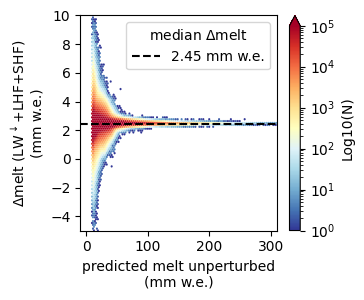

Median melt increase per 10W/m^2 dswrad increase: 0.930994987487793


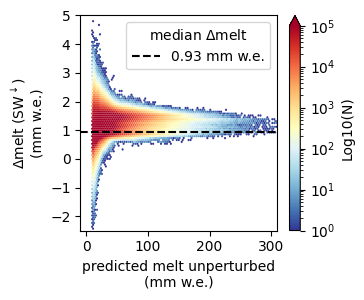

In [4]:
# plot melt change versus unperturbed predicted melt

for v in ['energyin', 'dswrad']:
    ds_zone = ds_pos

    pred_vals = ds_zone['snmel_pred'].values.ravel()
    mask_val = ~np.isnan(pred_vals)
    perturb_vals = ds_zone[f'snmel_{v}_pred'].values.ravel()

    pred_vals = pred_vals[mask_val]
    perturb_vals = perturb_vals[mask_val]

    diff = perturb_vals - pred_vals

    ylim = ylims[v.split('_')[0]]
    ymin, ymax = ylim
    xmin = -10
    xmax = 310

    med_val = np.median(diff)
    print(f'Median melt increase per 10W/m^2 {v} increase: {med_val}')

    fig, ax = plt.subplots(figsize=(3.7,3.1))
    ax.axhline(y=med_val, color='k', linestyle='--', label=f'{med_val:.2f} mm w.e.')

    count_limit = 1.e5
    cb = ax.hexbin(pred_vals, diff, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1, vmax=count_limit,
                    extent=(xmin, xmax, ymin, ymax),)

    plt.xlabel('predicted melt unperturbed\n(mm w.e.)')
    plt.ylabel(rf'$\Delta$melt ({variables_labels[v]})'+'\n(mm w.e.)')
    
    counts = cb.get_array()

    if counts.max() > count_limit:
        cb.set_clim(1, count_limit)
        cbar = plt.colorbar(cb, ax=ax, extend='max', label='Log10(N)')
    else:
        cbar = plt.colorbar(cb, ax=ax, label='Log10(N)')

    # ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ylim)

    ax.set_yticks(yticks[v.split('_')[0]])
    plt.legend(loc='upper right', frameon=True, title=r'median $\Delta$melt')
    plt.tight_layout()
    plt.savefig(os.path.sep.join([fig_dir, f'hexbin_meltincrease_{v}_{data_spec}_{model_name}_g10.pdf']), bbox_inches='tight')
    plt.show()

Median melt increase per 10W/m^2 dswrad increase: 0.930994987487793


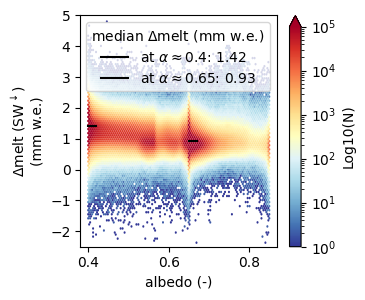

In [5]:
# plot melt change versus albedo

for v in ['dswrad']:
   
    ds_zone = ds_pos

    pred_vals = ds_zone['snmel_pred'].values.ravel()
    mask_val = ~np.isnan(pred_vals)
    perturb_vals = ds_zone[f'snmel_{v}_pred'].values.ravel()
    albedo_vals = ds_zone['albedom'].values.ravel()
    albedo_vals = albedo_vals[mask_val]

    pred_vals = pred_vals[mask_val]
    perturb_vals = perturb_vals[mask_val]

    diff = perturb_vals - pred_vals

    ylim = ylims[v.split('_')[0]]
    ymin, ymax = ylim

    xmin = 0.38
    xmax = 0.87

    med_val = np.median(diff)
    med_val_40 = np.median(diff[(albedo_vals-0.4)<=0.02])
    med_val_65 = np.median(diff[(albedo_vals-0.65)<=0.02])

    print(f'Median melt increase per 10W/m^2 {v} increase: {med_val}')

    fig, ax = plt.subplots(figsize=(3.7,3.1))
    ax.plot([0.4, 0.42], [med_val_40, med_val_40], 'k-', label=rf'at $\alpha\approx$0.4: {med_val_40:.2f}')
    ax.plot([0.65, 0.67], [med_val_65, med_val_65], 'k-', label=rf'at $\alpha\approx$0.65: {med_val_65:.2f}')

    count_limit = 1.e5
    cb = ax.hexbin(albedo_vals, diff, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1, vmax=count_limit,
                    extent=(xmin, xmax, ymin, ymax),)

    plt.xlabel('albedo (-)')
    plt.ylabel(rf'$\Delta$melt ({variables_labels[v]})'+'\n(mm w.e.)')
    
    counts = cb.get_array()

    if counts.max() > count_limit:
        cb.set_clim(1, count_limit)
        cbar = plt.colorbar(cb, ax=ax, extend='max', label='Log10(N)')
    else:
        cbar = plt.colorbar(cb, ax=ax, label='Log10(N)')


    #ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ylim)
    ax.set_yticks(yticks[v.split('_')[0]])
    plt.legend(loc='upper right', frameon=True, title=r'median $\Delta$melt (mm w.e.)')
    plt.tight_layout()
    plt.savefig(os.path.sep.join([fig_dir, f'hexbin_meltincrease_{v}_vs_albedo_perturb_{data_spec}_{model_name}_g10.pdf']), bbox_inches='tight')
    plt.show()

Median melt increase per 10W/m^2 energyin increase: 2.4499053955078125


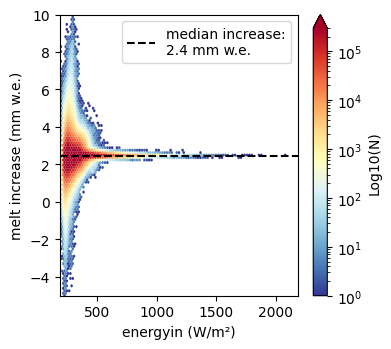

Median melt increase per 10W/m^2 dswrad increase: 0.930994987487793


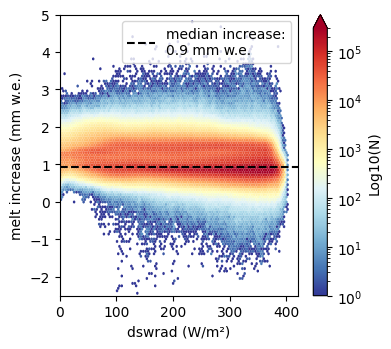

In [6]:
# plot change in melt with respect to energy flux change vs unperturbed energy flux input

for v in ['energyin', 'dswrad']:
   
    ds_zone = ds_pos
    pred_vals = ds_zone['snmel_pred'].values.ravel()
    mask_val = ~np.isnan(pred_vals)
    perturb_vals = ds_zone[f'snmel_{v}_pred'].values.ravel()

    pred_vals = pred_vals[mask_val]
    perturb_vals = perturb_vals[mask_val]

    diff = perturb_vals - pred_vals

    var_vals = ds_zone[v].values.ravel()
    var_vals = var_vals[mask_val]

    ylim = ylims[v]
    ymin, ymax = ylim

    xmin = var_vals.min()*1.05
    xmax = var_vals.max()*1.05

    med_val = np.median(diff)

    print(f'Median melt increase per 10W/m^2 {v} increase: {med_val}')

    fig, ax = plt.subplots(figsize=(4,3.6))
    ax.axhline(y=med_val, color='k', linestyle='--', label=f'median increase:\n{med_val:.1f} mm w.e.')

    count_limit = 3.e5
    cb = ax.hexbin(var_vals, diff, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1, vmax=count_limit,
                    extent=(xmin, xmax, ymin, ymax),)

    plt.xlabel(f'{v} (W/m²)')
    plt.ylabel('melt increase (mm w.e.)')
    
    counts = cb.get_array()

    if counts.max() > count_limit:
        cb.set_clim(1, count_limit)
        cbar = plt.colorbar(cb, ax=ax, extend='max', label='Log10(N)')
    else:
        cbar = plt.colorbar(cb, ax=ax, label='Log10(N)')

    # ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ylim)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    #plt.savefig(os.path.sep.join([fig_dir, f'hexbin_meltincrease_{v}_perinput_{data_spec}_{model_spec}.pdf']), bbox_inches='tight')
    plt.show()

## Explore negative sensitivities

In [7]:
ds_pos = ds_pos.assign(snmel_pred_diff_energyin_perturb=ds_pos['snmel_energyin_pred']-ds_pos['snmel_pred'])
ds_pos = ds_pos.assign(snmel_pred_diff_dswrad_perturb=ds_pos['snmel_dswrad_pred']-ds_pos['snmel_pred'])

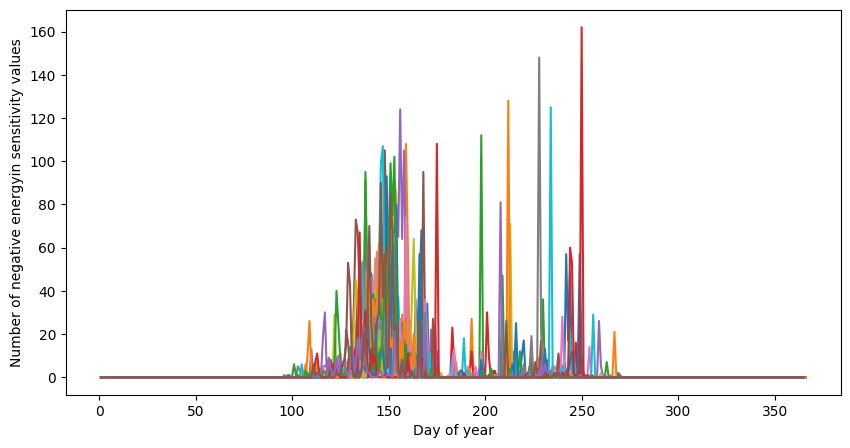

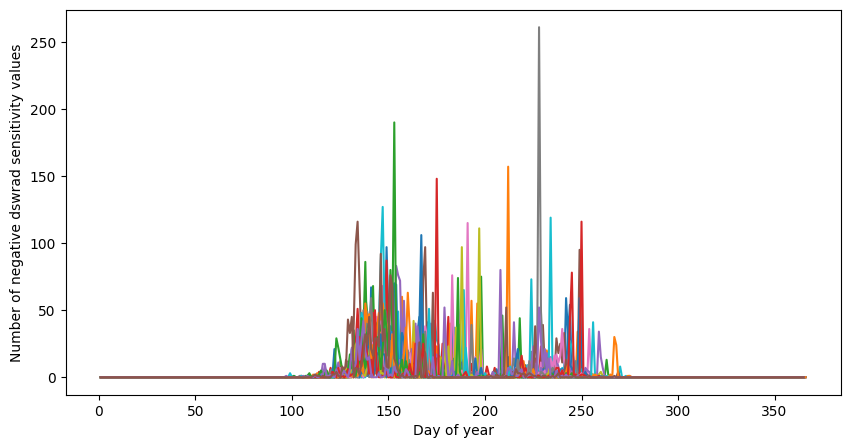

In [8]:
# Negative sensitivities over time
mask_neg_energyin = ds_pos['snmel_pred_diff_energyin_perturb']<0
neg_energy_values = mask_neg_energyin.sum(dim=['x','y'])

fig, ax = plt.subplots(figsize=(10, 5))

for year, da_year in neg_energy_values.groupby("time.year"):
    ax.plot(
        da_year.time.dt.dayofyear,
        da_year,
        label=str(year)
    )

ax.set_xlabel("Day of year")
ax.set_ylabel("Number of negative energyin sensitivity values")
plt.show()



mask_neg_dswrad = ds_pos['snmel_pred_diff_dswrad_perturb']<0
neg_dswrad_values = mask_neg_dswrad.sum(dim=['x','y'])

fig, ax = plt.subplots(figsize=(10, 5))

for year, da_year in neg_dswrad_values.groupby("time.year"):
    ax.plot(
        da_year.time.dt.dayofyear,
        da_year,
        label=str(year)
    )

ax.set_xlabel("Day of year")
ax.set_ylabel("Number of negative dswrad sensitivity values")
plt.show()

In [9]:
# find datetimes with negative sensitivities w.r.t. energyin
neg_energy_values = mask_neg_energyin.sum(dim=['x', 'y'])

# Sort by values (descending)
sorted_neg_energy = neg_energy_values.sortby(neg_energy_values, ascending=False)
top10 = sorted_neg_energy.isel(time=slice(0, 10))

for t, v in zip(top10.time.values, top10.values):
    print(t, v)

2088-09-06T12:00:00.000000000 162
2082-08-16T12:00:00.000000000 148
2086-07-31T12:00:00.000000000 128
2084-08-21T12:00:00.000000000 125
2089-06-05T12:00:00.000000000 124
2077-07-17T12:00:00.000000000 112
2098-06-24T12:00:00.000000000 108
2086-06-08T12:00:00.000000000 108
2094-05-27T12:00:00.000000000 107
2089-06-07T12:00:00.000000000 105


In [10]:
# negative sensitivity w.r.t. energyin
mask_neg_energyin = ds_pos['snmel_pred_diff_energyin_perturb']<0
neg_energy_values = mask_neg_energyin.sum(dim=['x','y'])

# no melt predicted at previous time step
prev_nan_mask = (ds["snmel_pred"]<1).shift(time=1)
prev_nan_neg_energyin_mask = mask_neg_energyin & prev_nan_mask
prev_nan_neg_energyin_values = prev_nan_neg_energyin_mask.sum(dim=['x','y'])

# no true melt at previous time step
prevtrue_nan_mask = (ds["snmel_true"]<1)
prevtrue_nan_neg_energyin_mask = mask_neg_energyin & prevtrue_nan_mask
prevtrue_nan_neg_energyin_values = prevtrue_nan_neg_energyin_mask.sum(dim=['x','y'])


# Sort by values (descending)
sorted_neg_energy = neg_energy_values.sortby(neg_energy_values, ascending=False)
top10 = sorted_neg_energy.isel(time=slice(0, 10))

for t in top10.time.values:
    neg = neg_energy_values.sel(time=t).values.item()
    neg_where_noprevpredict = prev_nan_neg_energyin_values.sel(time=t).values.item()
    neg_where_noprevtrue = prevtrue_nan_neg_energyin_values.sel(time=t).values.item()


    print(
        f"{t} | "
        f"negative: {neg:6d} | "
        f"prev_nan & negative: {neg_where_noprevpredict:6d} | "
        f"prevtrue_nan & negative: {neg_where_noprevtrue:6d}"
    )

2088-09-06T12:00:00.000000000 | negative:    162 | prev_nan & negative:      0 | prevtrue_nan & negative:      7
2082-08-16T12:00:00.000000000 | negative:    148 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2086-07-31T12:00:00.000000000 | negative:    128 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2084-08-21T12:00:00.000000000 | negative:    125 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2089-06-05T12:00:00.000000000 | negative:    124 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2077-07-17T12:00:00.000000000 | negative:    112 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2098-06-24T12:00:00.000000000 | negative:    108 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2086-06-08T12:00:00.000000000 | negative:    108 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2094-05-27T12:00:00.000000000 | negative:    107 | prev_nan & negative:      0 | prevtrue_nan & 

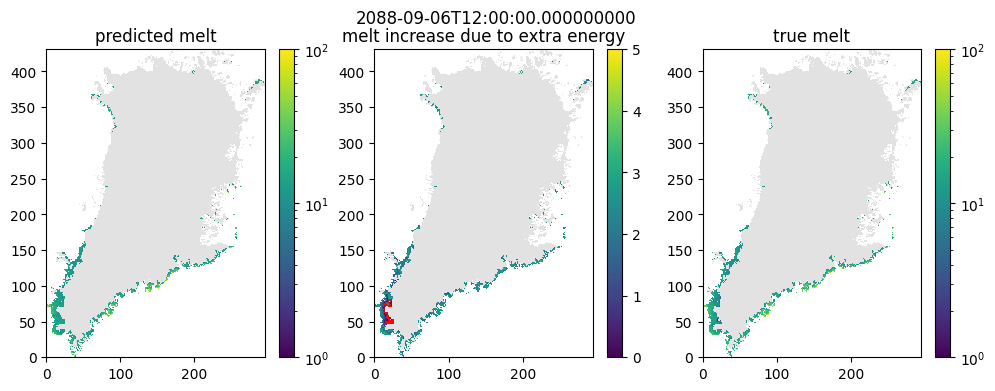

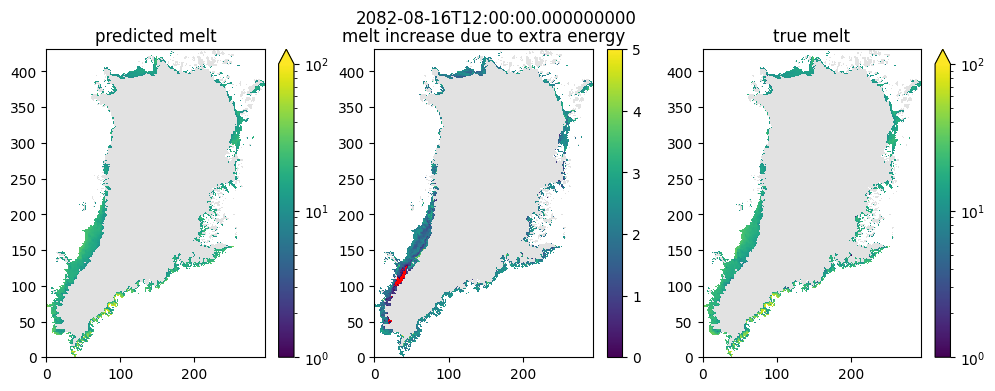

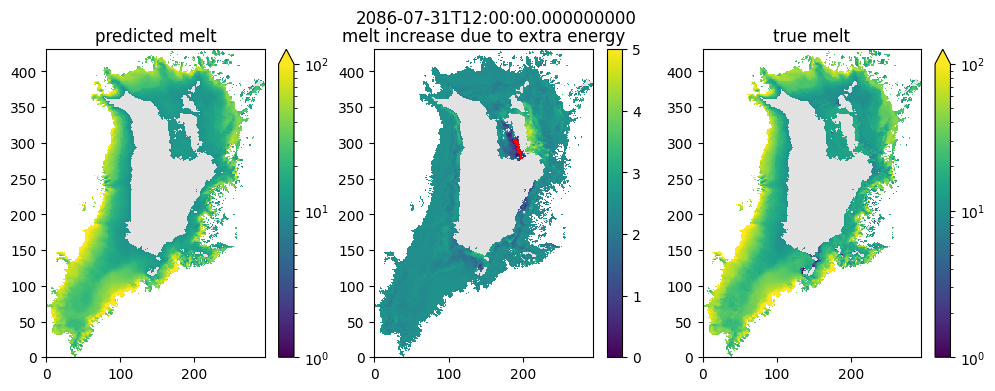

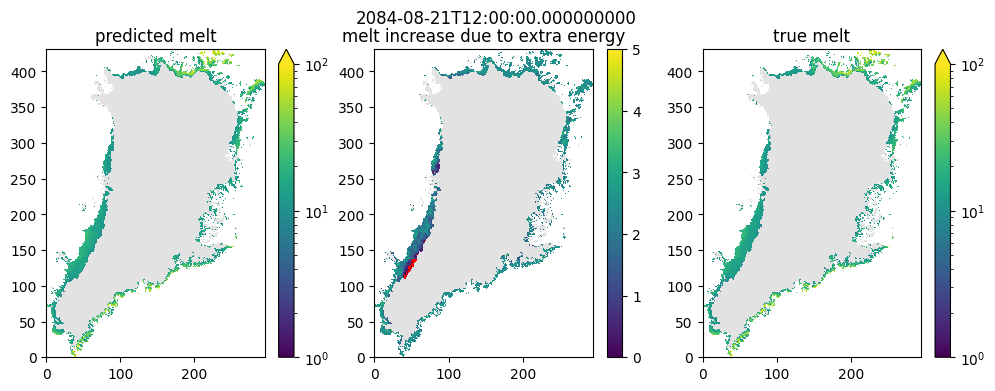

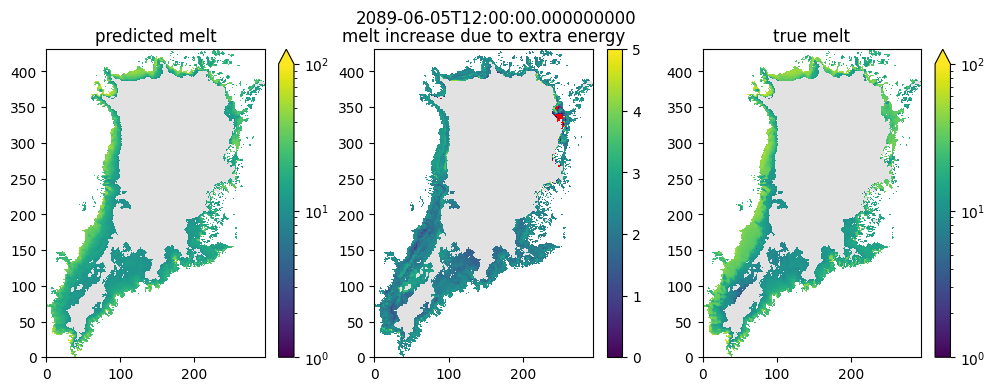

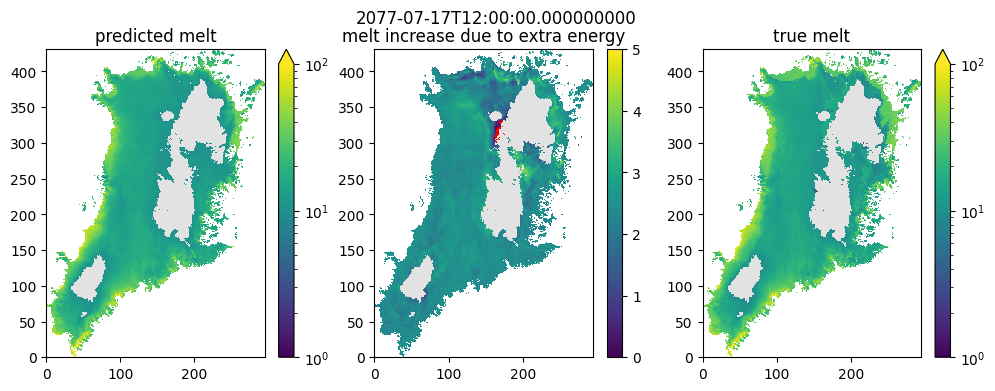

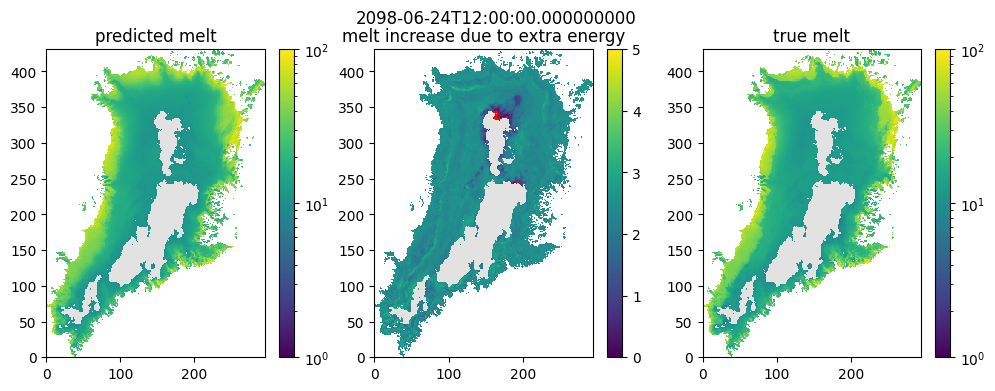

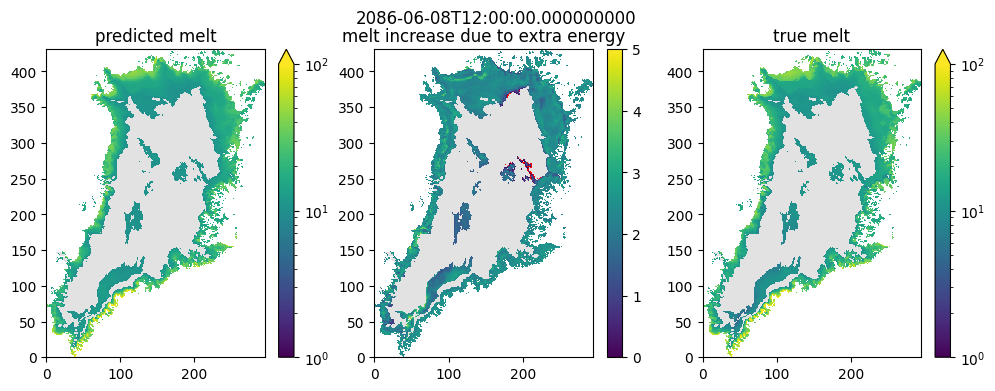

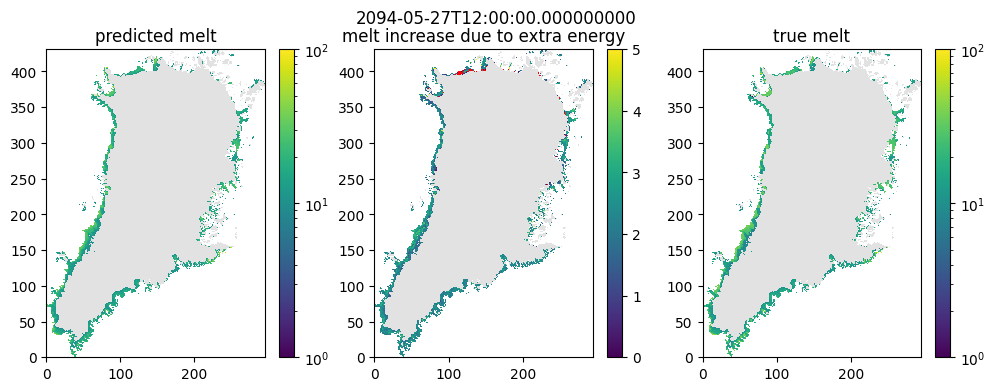

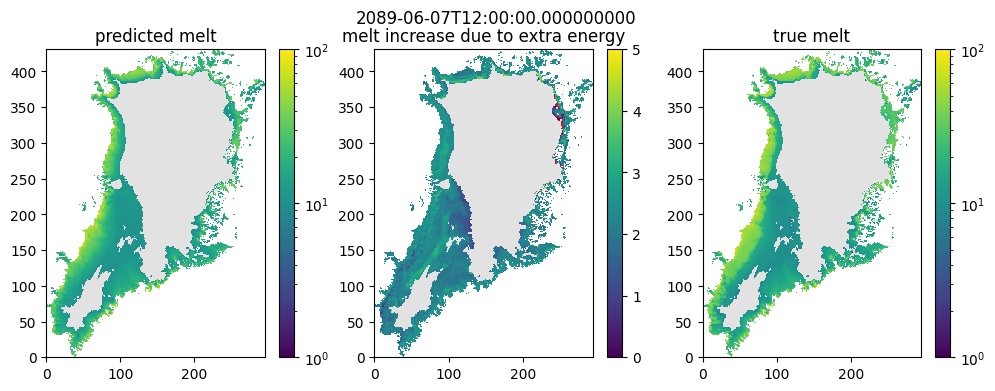

In [11]:
# plot sensitivity w.r.t extra melt
# in red where sensitivity is negative

from matplotlib.colors import LogNorm
cmap = plt.cm.viridis.copy()
cmap.set_under('red')

cmap_res = plt.cm.seismic.copy()
cmap_res.set_bad((0, 0, 0, 0.0)) 

threshold = 0
for t in top10.time.values:
    bg = xr.where(ds['snmel_pred'].sel(time=t-pd.Timedelta(days=1)).notnull(),1,np.nan)

    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12,4))
    plt.suptitle(t)
    ax1.set_title('predicted melt')
    ax1.pcolormesh(bg, cmap='Greys', vmin=0, vmax=5)
    extend = 'max' if np.nanmax(ds['snmel_pred'].sel(time=t).values) > 100 else 'neither'
    cb = ax1.pcolormesh(ds_pos['snmel_pred'].sel(time=t), norm=LogNorm(vmin=1, vmax=100))
    plt.colorbar(cb, extend=extend)

    ax2.set_title('melt increase due to extra energy')
    ax2.pcolormesh(bg, cmap='Greys', vmin=0, vmax=5)
    cb = ax2.pcolormesh(ds_pos['snmel_pred_diff_energyin_perturb'].sel(time=t), cmap=cmap, vmin=0, vmax=5)
    plt.colorbar(cb)

    ax3.set_title('true melt')
    ax3.pcolormesh(bg, cmap='Greys', vmin=0, vmax=5)
    extend = 'max' if np.nanmax(ds['snmel_true'].sel(time=t).values) > 100 else 'neither'
    cb = ax3.pcolormesh(ds_pos['snmel_true'].sel(time=t), norm=LogNorm(vmin=1, vmax=100))
    plt.colorbar(cb, extend=extend)

    plt.show()

In [12]:
# negative sensitivity w.r.t. dswrad
mask_neg_dswrad = ds_pos['snmel_pred_diff_dswrad_perturb']<0
neg_dswrad_values = mask_neg_dswrad.sum(dim=['x','y'])

# no melt predicted at previous time step
prev_nan_mask = (ds["snmel_pred"]<1).shift(time=1)
prev_nan_neg_energyin_mask = mask_neg_dswrad & prev_nan_mask
prev_nan_neg_energyin_values = prev_nan_neg_energyin_mask.sum(dim=['x','y'])

# no true melt at previous time step
prevtrue_nan_mask = (ds["snmel_true"]<1).shift(time=1)
prevtrue_nan_neg_energyin_mask = mask_neg_dswrad & prevtrue_nan_mask
prevtrue_nan_neg_energyin_values = prevtrue_nan_neg_energyin_mask.sum(dim=['x','y'])


# Sort by values (descending)
sorted_neg_energy = neg_dswrad_values.sortby(neg_dswrad_values, ascending=False)
top10 = sorted_neg_energy.isel(time=slice(0, 10))

for t in top10.time.values:
    neg = neg_dswrad_values.sel(time=t).values.item()
    neg_where_noprevpredict = prev_nan_neg_energyin_values.sel(time=t).values.item()
    neg_where_noprevtrue = prevtrue_nan_neg_energyin_values.sel(time=t).values.item()


    print(
        f"{t} | "
        f"negative: {neg:6d} | "
        f"prev_nan & negative: {neg_where_noprevpredict:6d} | "
        f"prevtrue_nan & negative: {neg_where_noprevtrue:6d}"
    )

2082-08-16T12:00:00.000000000 | negative:    261 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2097-06-02T12:00:00.000000000 | negative:    190 | prev_nan & negative:      0 | prevtrue_nan & negative:     20
2086-07-31T12:00:00.000000000 | negative:    157 | prev_nan & negative:      0 | prevtrue_nan & negative:      4
2098-06-24T12:00:00.000000000 | negative:    148 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2094-05-27T12:00:00.000000000 | negative:    127 | prev_nan & negative:      0 | prevtrue_nan & negative:     19
2084-08-21T12:00:00.000000000 | negative:    119 | prev_nan & negative:      0 | prevtrue_nan & negative:      0
2090-05-14T12:00:00.000000000 | negative:    116 | prev_nan & negative:      0 | prevtrue_nan & negative:     15
2088-09-06T12:00:00.000000000 | negative:    116 | prev_nan & negative:      0 | prevtrue_nan & negative:      3
2081-07-10T12:00:00.000000000 | negative:    115 | prev_nan & negative:      0 | prevtrue_nan & 

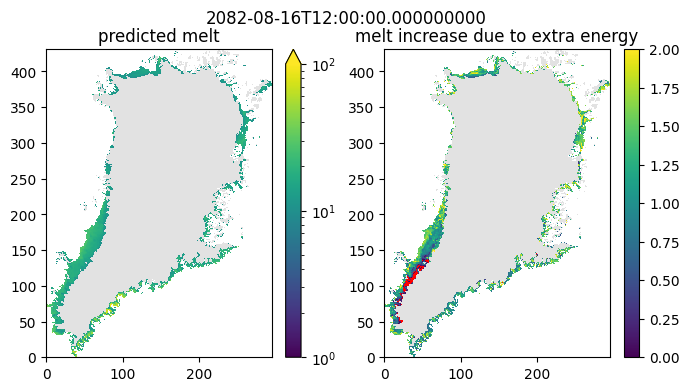

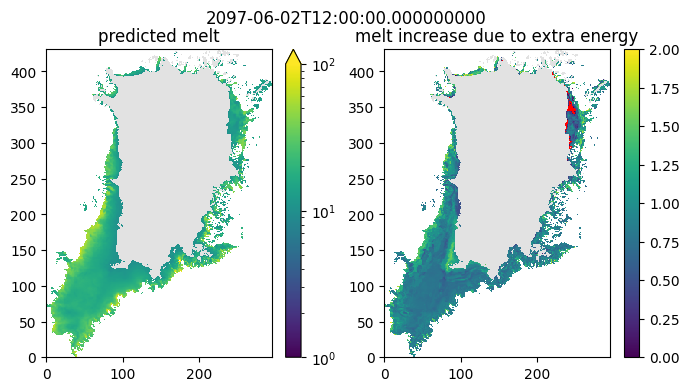

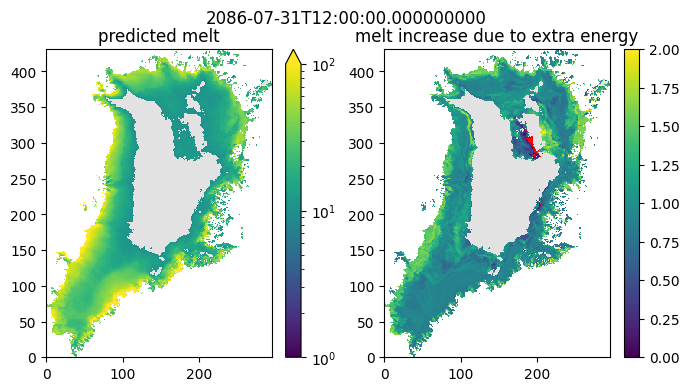

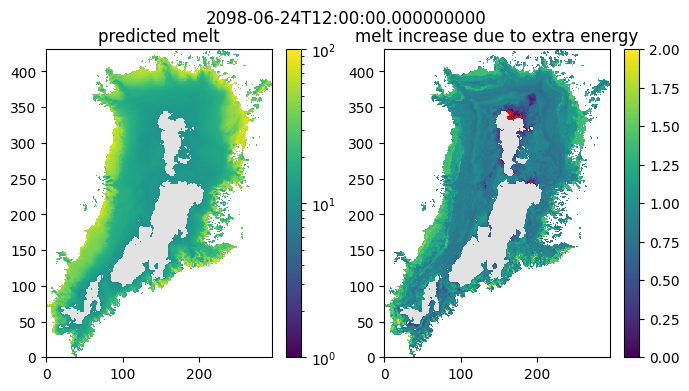

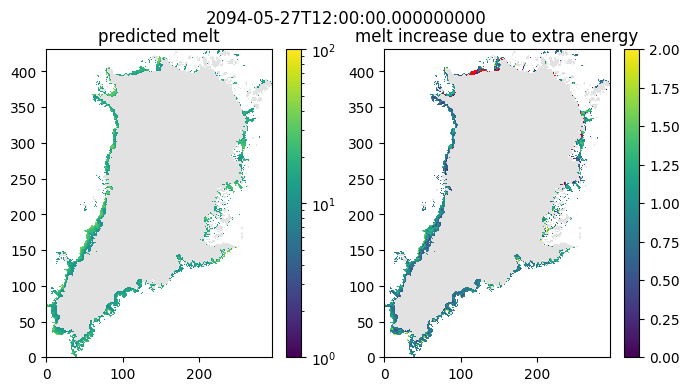

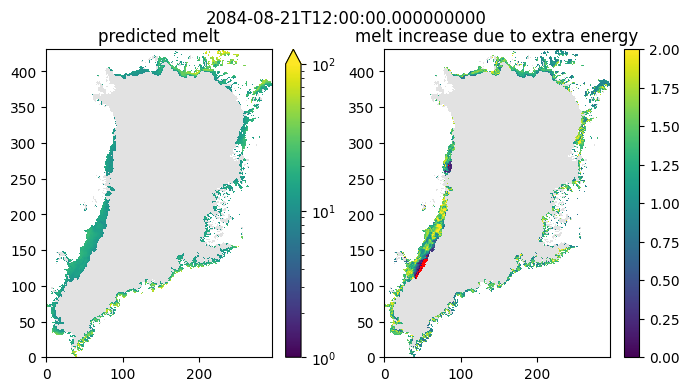

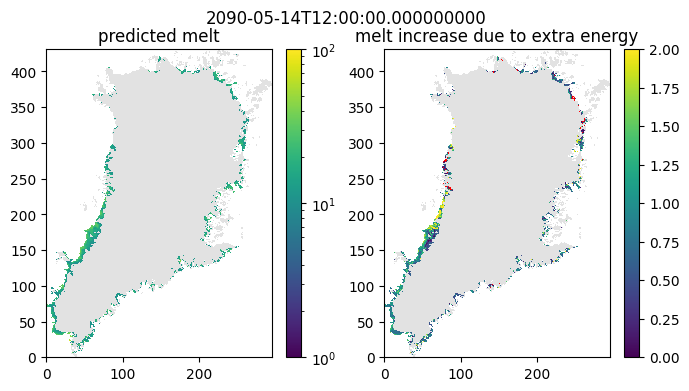

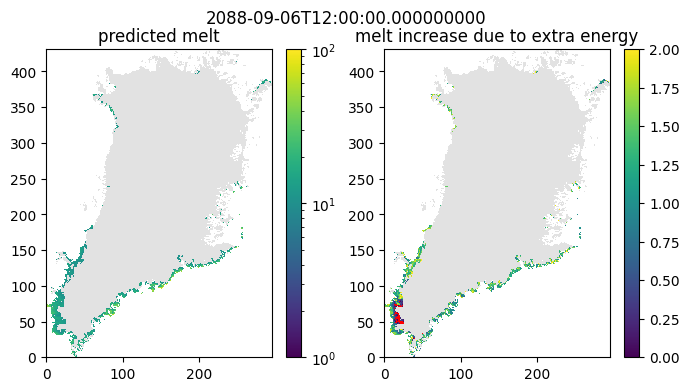

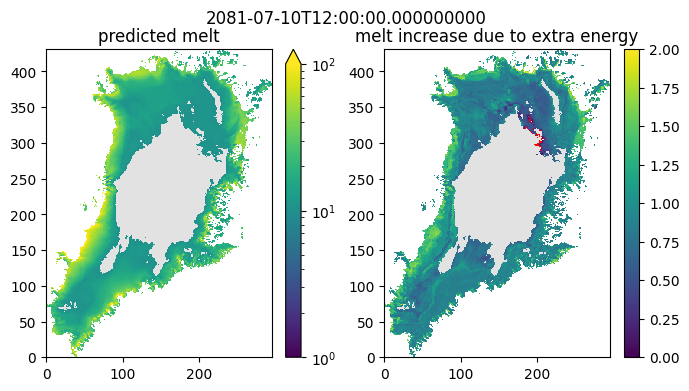

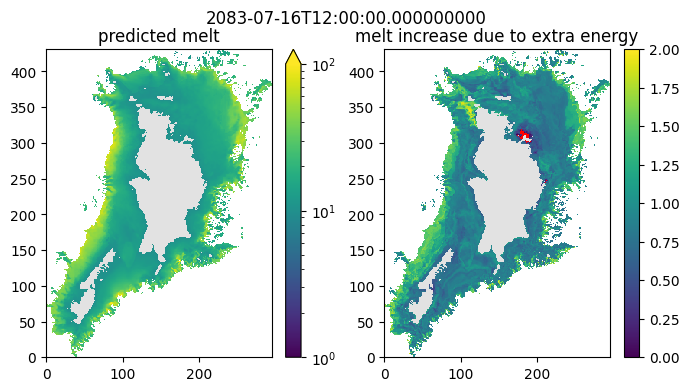

In [13]:
# plot sensitivity w.r.t extra melt
# in red where sensitivity is negative

from matplotlib.colors import LogNorm
cmap = plt.cm.viridis.copy()
cmap.set_under('red')

threshold = 0
for t in top10.time.values:
    bg = xr.where(ds['snmel_pred'].sel(time=t-pd.Timedelta(days=1)).notnull(),1,np.nan)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8,4))
    plt.suptitle(t)
    ax1.set_title('predicted melt')
    ax1.pcolormesh(bg, cmap='Greys', vmin=0, vmax=5)
    extend = 'max' if np.nanmax(ds['snmel_pred'].sel(time=t).values) > 100 else 'neither'
    cb = ax1.pcolormesh(ds_pos['snmel_pred'].sel(time=t), norm=LogNorm(vmin=1, vmax=100))
    plt.colorbar(cb, extend=extend)

    ax2.set_title('melt increase due to extra energy')
    ax2.pcolormesh(bg, cmap='Greys', vmin=0, vmax=5)
    cb = ax2.pcolormesh(ds_pos['snmel_pred_diff_dswrad_perturb'].sel(time=t), cmap=cmap, vmin=0, vmax=2)
    plt.colorbar(cb)

    plt.show()

In [ ]:
# models with their best iteration
MODEL_SPECS = {'ERAI':17, 'CESM2':18, 'ECE':4, 'CESM2future':0, 'ECEfuture':11}

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for data_spec, iter in MODEL_SPECS.items():
    model_dir = os.path.sep.join([base_dir, 'output', f'repeated_{data_spec}_modularNNEBM_log', ])
    data_dir = os.path.sep.join([model_dir, f'perturbation_study_{iter}', f'pred_perturbed.zarr'])
    ds_perturb = xr.open_zarr(data_dir)

    pred_dir = os.path.sep.join([model_dir, f'pred_data_{data_spec}.zarr'])
    ds_pred = xr.open_zarr(pred_dir).sel(iteration=iter)
    ds_pred

    if 'future' in data_spec:
        data_in_dir = os.path.sep.join([base_dir, 'data', 'processed', f'HIRHAM5-{data_spec.split("future")[0]}', 'future'])
        zones_file = os.path.sep.join([data_in_dir, 'GRLzones_future.zarr'])
    else:
        data_in_dir = os.path.sep.join([base_dir, 'data', 'processed', f'HIRHAM5-{data_spec}', 'v_04'])
        zones_file = os.path.sep.join([data_in_dir, 'GRLzones.zarr'])
    ds_in = xr.open_zarr(os.path.sep.join([data_in_dir, 'base_dataset.zarr'])).sel(time=ds_perturb['time'])[['dswrad', 'energyin', 'albedom']]
    ds_in = ds_in.set_index(z=["y", "x"]).unstack("z")

    ds_zones = xr.open_zarr(zones_file).set_index(z=["y", "x"]).unstack("z")

    ds = xr.merge([ds_in, ds_pred["snmel_pred"], ds_perturb[["snmel_true", "snmel_energyin_pred", "snmel_dswrad_pred"]], ds_zones])
    ds = ds.unify_chunks()

    mask = ds['snmel_pred'] > 1
    ds_pos = ds.where(mask)
    
    ds_pos = ds_pos.assign(diff_energyin=ds_pos["snmel_energyin_pred"] - ds_pos["snmel_pred"])
    ds_pos = ds_pos.assign(diff_dswrad=ds_pos["snmel_dswrad_pred"] - ds_pos["snmel_pred"])
    
    df = ds_pos.to_dataframe().reset_index()
    df["month"] = df["time"].dt.month

    sns.boxplot(
        data=df,
        x="month",
        y="diff_energyin",
        showfliers=False,
        ax=ax1,
    )

    plt.show()

/data1/env_FirnML/lib/python3.11/site-packages/xarray/structure/chunks.py:229: PerformanceWarning: Increasing number of chunks by factor of 10
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)


In [ ]:
# Per zone
zones = np.unique(ds['zones'].values)
zones = list(zones[~np.isnan(zones)])
zones = zones
zones_label = {0:'all', 1:'ablation', 2:'percolation', 3:'dry'}

for v in ['energyin', 'dswrad']:
    print(v)
    for z in zones:
        print(zones_label[z])
        if z == 0:
            ds_zone = ds_pos
        else:
            ds_zone = ds_pos.where(ds_pos['zones']==z)

        pred_vals = ds_zone['snmel_pred'].values.ravel()
        mask_val = ~np.isnan(pred_vals)
        perturb_vals = ds_zone[f'snmel_{v}_pred'].values.ravel()

        pred_vals = pred_vals[mask_val]
        perturb_vals = perturb_vals[mask_val]

        diff = perturb_vals - pred_vals

        ylim = ylims[v]
        ymin, ymax = ylim

        xmin = -10
        xmax = 310

        med_val = np.median(diff)

        print(f'Median melt increase per 10W/m^2 {v} increase: {med_val}')

        fig, ax = plt.subplots(figsize=(4,3.6))
        ax.axhline(y=med_val, color='k', linestyle='--', label=f'median increase:\n{med_val:.1f} mm w.e.')

        count_limit = 3.e5
        cb = ax.hexbin(pred_vals, diff, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1, vmax=count_limit,
                       extent=(xmin, xmax, ymin, ymax),)

        plt.xlabel('predicted melt unperturbed (mm w.e.)')
        plt.ylabel('melt increase (mm w.e.)')
        
        counts = cb.get_array()

        if counts.max() > count_limit:
            cb.set_clim(1, count_limit)
            cbar = plt.colorbar(cb, ax=ax, extend='max', label='Log10(N)')
        else:
            cbar = plt.colorbar(cb, ax=ax, label='Log10(N)')

        # ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ylim)
        plt.legend(loc='upper right', frameon=True)
        plt.tight_layout()
        plt.show()

In [ ]:
# per month
months = [1,2,3,4,5,6,7,8,9,10,11,12]

for v in ['energyin', 'dswrad']:
    print(v)
    for m in months:
        if m == 0:
            ds_zone = ds_pos
        else:
            month_name = calendar.month_name[m]
            print(month_name)
            ds_zone = ds_pos.sel(time=ds_pos.time.dt.month == m)

        pred_vals = ds_zone['snmel_pred'].values.ravel()
        mask_val = ~np.isnan(pred_vals)
        perturb_vals = ds_zone[f'snmel_{v}_pred'].values.ravel()

        pred_vals = pred_vals[mask_val]
        perturb_vals = perturb_vals[mask_val]

        diff = perturb_vals - pred_vals

        ylim = ylims[v]
        ymin, ymax = ylim

        xmin = -10
        xmax = 310

        med_val = np.median(diff)

        print(f'Median melt increase per 10W/m^2 {v} increase: {med_val}')

        fig, ax = plt.subplots(figsize=(4,3.6))
        ax.axhline(y=med_val, color='k', linestyle='--', label=f'median increase:\n{med_val:.1f} mm w.e.')

        count_limit = 3.e5
        cb = ax.hexbin(pred_vals, diff, bins='log', cmap='RdYlBu_r', linewidths=(0,), mincnt=1, vmin=1, vmax=count_limit,
                        extent=(xmin, xmax, ymin, ymax),)

        plt.xlabel('predicted melt unperturbed (mm w.e.)')
        plt.ylabel('melt increase (mm w.e.)')
        
        counts = cb.get_array()

        if counts.max() > count_limit:
            cb.set_clim(1, count_limit)
            cbar = plt.colorbar(cb, ax=ax, extend='max', label='Log10(N)')
        else:
            cbar = plt.colorbar(cb, ax=ax, label='Log10(N)')

        # ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ylim)
        plt.legend(loc='upper right', frameon=True)
        plt.tight_layout()
        plt.show()

## Explore sensitivities w.r.t. previous days' energy flux perturbations

In [ ]:
no_phys_dir = os.path.sep.join([base_dir, 'figures', 'perturbation', data_spec])
phys_dir = os.path.sep.join([base_dir, 'figures', 'perturbation', data_spec+'mono100'])


In [ ]:
perturb_vars = ['energyin', 'dswrad']
perturb_vars_preceeding = [f"{var}_d-{k}" for var in perturb_vars for k in range(1, 10)]
perturb_vars_preceeding

In [ ]:
vars_ = ["energyin"] + [f"energyin_d-{k}" for k in range(1, 10)]

results = {}

# Compute once
valid_mask = np.isfinite(ds_pos["snmel_pred"].compute().values.ravel())

for v in vars_:
    diff = (
        ds_pos[f"snmel_{v}_pred"]
        - ds_pos["snmel_pred"]
    ).compute().values.ravel()

    diff = diff[valid_mask]

    results[v] = [
        np.min(diff),
        *np.percentile(diff, [5, 25, 50, 75, 95]),
        np.max(diff),
    ]

df_percentiles = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["min", "p05", "p25", "p50", "p75", "p95", "max"],
)

df_percentiles.to_csv(os.path.sep.join([fig_dir, 'stats_energyperturbation.csv']))
df_percentiles


In [ ]:
vars_ = ["dswrad"] + [f"dswrad_d-{k}" for k in range(1, 10)]


results = {}

# Compute once
valid_mask = np.isfinite(ds_pos["snmel_pred"].compute().values.ravel())

for v in vars_:
    diff = (
        ds_pos[f"snmel_{v}_pred"]
        - ds_pos["snmel_pred"]
    ).compute().values.ravel()

    diff = diff[valid_mask]

    results[v] = [
        np.min(diff),
        *np.percentile(diff, [5, 25, 50, 75, 95]),
        np.max(diff),
    ]

df_percentiles = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["min", "p05", "p25", "p50", "p75", "p95", "max"],
)

df_percentiles.to_csv(os.path.sep.join([fig_dir, 'stats_dswradperturbation.csv']))
df_percentiles

In [ ]:
import seaborn as sns
colors = sns.color_palette('colorblind')
colors

energyin_file = '/stats_energyperturbation.csv'

df_nophys = pd.read_csv(no_phys_dir+energyin_file, index_col=[0])
df_phys = pd.read_csv(phys_dir+energyin_file, index_col=[0])

fig, ax = plt.subplots(figsize=(8, 4))

stats1 = [
    {
        "label": idx,
        "whislo": row["p05"],    # lower whisker
        "q1": row["p25"],
        "med": row["p50"],
        "q3": row["p75"],
        "whishi": row["p95"],    # upper whisker
        "fliers": []
    }
    for idx, row in df_nophys.iterrows()
]

stats2 = [
    {
        "label": idx,
        "whislo": row["p05"],
        "q1": row["p25"],
        "med": row["p50"],
        "q3": row["p75"],
        "whishi": row["p95"],
        "fliers": []
    }
    for idx, row in df_phys.iterrows()
]

n = len(df_nophys)

# positions for paired boxplots
pos1 = np.arange(n) - 0.2
pos2 = np.arange(n) + 0.2

ax.bxp(
    stats1,
    positions=pos1,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor=colors[4], alpha=0.5),
    medianprops=dict(color=colors[4], linewidth=2)
    
)

ax.bxp(
    stats2,
    positions=pos2,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor=colors[-1], alpha=0.5),
    medianprops=dict(color=colors[-1], linewidth=2)
)

ax.set_xticks(np.arange(n))
ax.set_xticklabels(df_nophys.index, rotation=45, ha="right")

ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color=colors[4]),
     plt.Rectangle((0, 0), 1, 1, color=colors[-1])],
    ["no physics", "with monotonicity loss"]
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)

ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

In [ ]:
energyin_file = '/stats_dswradperturbation.csv'

df_nophys = pd.read_csv(no_phys_dir+energyin_file, index_col=[0])
df_phys = pd.read_csv(phys_dir+energyin_file, index_col=[0])

fig, ax = plt.subplots(figsize=(8, 4))

stats1 = [
    {
        "label": idx,
        "whislo": row["p05"],    # lower whisker
        "q1": row["p25"],
        "med": row["p50"],
        "q3": row["p75"],
        "whishi": row["p95"],    # upper whisker
        "fliers": []
    }
    for idx, row in df_nophys.iterrows()
]

stats2 = [
    {
        "label": idx,
        "whislo": row["p05"],
        "q1": row["p25"],
        "med": row["p50"],
        "q3": row["p75"],
        "whishi": row["p95"],
        "fliers": []
    }
    for idx, row in df_phys.iterrows()
]

n = len(df_nophys)

# positions for paired boxplots
pos1 = np.arange(n) - 0.2
pos2 = np.arange(n) + 0.2

ax.bxp(
    stats1,
    positions=pos1,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor=colors[4], alpha=0.5),
    medianprops=dict(color=colors[4], linewidth=2)
)

ax.bxp(
    stats2,
    positions=pos2,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor=colors[-1], alpha=0.5),
    medianprops=dict(color=colors[-1], linewidth=2)
    
)

ax.set_xticks(np.arange(n))
ax.set_xticklabels(df_nophys.index, rotation=45, ha="right")

ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color=colors[4]),
     plt.Rectangle((0, 0), 1, 1, color=colors[-1])],
    ["no physics", "with monotonicity loss"]
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.fill_between(np.linspace(xmin, xmax), ymin, color='lightgrey', alpha=0.4, zorder=-1)

ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()